
# Week 5: Vehicle-Based Urban Flood Detection

## Overview
This notebook introduces a **street-level urban flood intelligence workflow** where vehicles are used as reference objects for understanding flood severity in urban scenes. Instead of only asking whether a scene is flooded, this workflow uses **vehicle detection and crop extraction** to prepare the image for downstream flood-depth interpretation.

This is an important shift from remote sensing flood extent mapping to **street-level visual reasoning**. Vehicles act as scale-aware cues because water reaching tires, wheel hubs, doors, or chassis can indicate increasing severity.

## Learning Objectives
- Understand why vehicles are useful indicators of flood severity in urban imagery
- Review the logic of an object detection workflow
- Load an urban flood image and visualize detections
- Extract cropped regions around detected vehicles
- Understand why context-aware cropping matters
- Prepare outputs for later flood-depth classification

## Expected Outcome
By the end of this notebook, you should be able to explain and demonstrate the first stage of a vehicle-based urban flood analysis pipeline: detecting vehicles and generating relevant cropped regions for flood interpretation.



## Notebook Structure

1. Environment setup  
2. Why vehicles matter in flood analysis  
3. Pipeline overview  
4. Install and import required tools  
5. Example image loading  
6. Simulated object detection results  
7. Bounding box visualization  
8. Context-aware crop extraction  
9. Crop comparison  
10. Preparing data for next-stage analysis  
11. Mini exercise  
12. Weekly assignment  

> This notebook is structured as a **teaching notebook**. It includes conceptual explanations, practical Python code, and placeholders where a full detector such as YOLO-World can be plugged in later.


In [1]:

# Week 5 setup: imports and environment check

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print("Python version:", sys.version.split()[0])
print("Working directory:", os.getcwd())


Python version: 3.12.12
Working directory: /content


In [2]:

# Create output folder for this week

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "week05"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory ready:", OUTPUT_DIR)


Output directory ready: /content/outputs/week05



## Why Vehicles Matter in Urban Flood Detection

At street level, flood severity is often interpreted relative to visible urban objects. Vehicles are especially useful because they provide:
- a familiar physical reference
- approximate scale in the scene
- interaction cues between water and the object
- evidence for mobility disruption and safety risk

For example:
- **Level 0:** no meaningful water contact
- **Level 1:** water reaches tires
- **Level 2:** water reaches wheel hubs
- **Level 3:** water reaches doors or chassis
- **Level 4:** major body coverage, severe hazard

This makes vehicles helpful for **interpreting flood severity**, not just for detecting whether flooding exists.



## From Remote Sensing to Street-Level Intelligence

In Week 4, segmentation focused on mapping **where water exists** from satellite imagery.  
In Week 5, the question becomes more local and operational:

> **How severe is the flood around vehicles in this urban scene?**

That requires a different workflow:
1. Detect vehicles
2. Extract relevant image regions
3. Preserve surrounding water context
4. Send the crop to a downstream model for severity estimation

This notebook focuses on the **detection and cropping stage**.



## Pipeline Overview

A typical vehicle-based flood workflow can be summarized as:

1. Load street-level flood image  
2. Detect vehicles in the scene  
3. Generate bounding boxes  
4. Expand crops to include nearby water context  
5. Save cropped regions  
6. Pass crops to enhancement or classification models  
7. Aggregate results to produce an image-level severity estimate  

This week covers **steps 1 to 5**.


In [3]:

# Workflow summary table

pipeline_df = pd.DataFrame({
    "Step": [
        "Load image",
        "Detect vehicles",
        "Draw bounding boxes",
        "Expand crop regions",
        "Save cropped regions",
        "Classify flood severity",
        "Aggregate outputs"
    ],
    "Purpose": [
        "Read the street-level input scene",
        "Find candidate vehicles",
        "Visualize localized detections",
        "Preserve surrounding water texture and reflection context",
        "Prepare model-ready regions of interest",
        "Estimate flood level per crop",
        "Create a final scene-level decision"
    ]
})

pipeline_df


,Step,Purpose
0,Load image,Read the street-level input scene
1,Detect vehicles,Find candidate vehicles
2,Draw bounding boxes,Visualize localized detections
3,Expand crop regions,Preserve surrounding water texture and reflect...
4,Save cropped regions,Prepare model-ready regions of interest
5,Classify flood severity,Estimate flood level per crop
6,Aggregate outputs,Create a final scene-level decision



## Install and Import Required Tools

The full reference workflow uses a detector such as **YOLO-World**. In a real implementation, the following tools may be used:
- `ultralytics` for object detection
- `opencv-python` for image handling
- `Pillow` or `matplotlib` for visualization

The next cells show the structure you would use in a fresh environment.


In [4]:

# Install object detection dependencies if needed
# Uncomment in a fresh notebook environment

# %pip install ultralytics opencv-python pillow


In [5]:

# Example detector import
# Uncomment after installation

# from ultralytics import YOLO
# model = YOLO("yolov8n.pt")
# print("Detector ready")



## Create a Synthetic Urban Flood Scene

To make this notebook runnable everywhere, the next cell creates a **synthetic street-level flood scene** with simple vehicle-like objects and floodwater. This helps students understand the detection and cropping logic before using a real model.


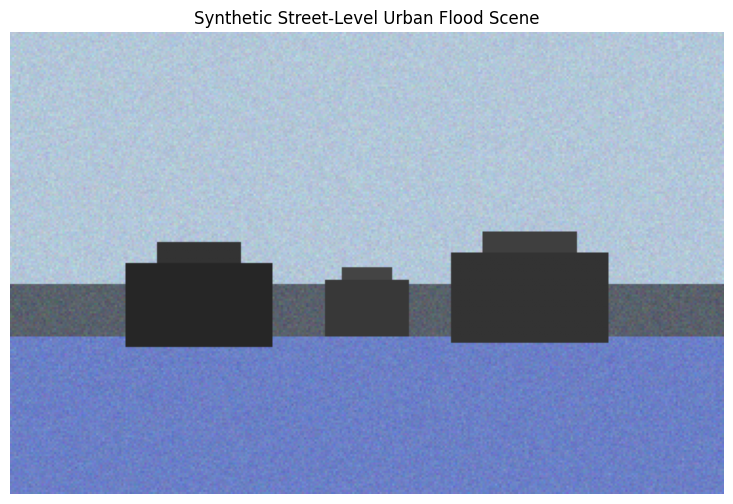

In [6]:

# Create a synthetic urban flood scene

np.random.seed(42)

scene = np.ones((220, 340, 3))
scene[..., 0] = 0.70
scene[..., 1] = 0.78
scene[..., 2] = 0.85

# Road
scene[120:220, :, 0] = 0.35
scene[120:220, :, 1] = 0.38
scene[120:220, :, 2] = 0.42

# Floodwater region
scene[145:220, :, 0] = 0.42
scene[145:220, :, 1] = 0.50
scene[145:220, :, 2] = 0.78

# Add mild texture/noise
scene += 0.03 * np.random.randn(*scene.shape)
scene = np.clip(scene, 0, 1)

# Vehicle 1
scene[110:150, 55:125, :] = 0.15
scene[100:110, 70:110, :] = 0.20

# Vehicle 2
scene[105:148, 210:285, :] = 0.20
scene[95:105, 225:270, :] = 0.25

# Small vehicle 3
scene[118:145, 150:190, :] = 0.22
scene[112:118, 158:182, :] = 0.27

plt.figure(figsize=(10, 6))
plt.imshow(scene)
plt.title("Synthetic Street-Level Urban Flood Scene")
plt.axis("off")
plt.show()



## Simulated Vehicle Detection Results

In a real workflow, the detector would predict bounding boxes automatically.  
For teaching purposes, the next cell defines **simulated detection boxes** that represent detector outputs.


In [7]:

# Simulated detection outputs: [x1, y1, x2, y2, confidence, class_name]

detections = [
    [55, 100, 125, 150, 0.94, "vehicle"],
    [210, 95, 285, 148, 0.91, "vehicle"],
    [150, 112, 190, 145, 0.83, "vehicle"]
]

detections_df = pd.DataFrame(detections, columns=["x1", "y1", "x2", "y2", "confidence", "class_name"])
detections_df


,x1,y1,x2,y2,confidence,class_name
0,55,100,125,150,0.94,vehicle
1,210,95,285,148,0.91,vehicle
2,150,112,190,145,0.83,vehicle


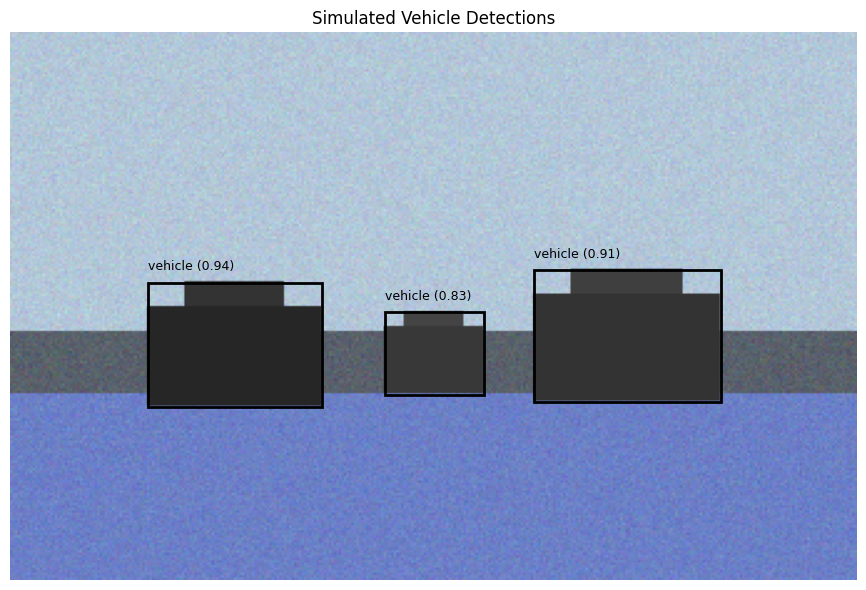

In [8]:

# Visualize bounding boxes on the scene

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(scene)

for det in detections:
    x1, y1, x2, y2, conf, cls = det
    width = x2 - x1
    height = y2 - y1

    rect = Rectangle((x1, y1), width, height, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x1, max(y1 - 5, 5), f"{cls} ({conf:.2f})", fontsize=9)

ax.set_title("Simulated Vehicle Detections")
ax.axis("off")
plt.tight_layout()
plt.show()



## Why Context-Aware Cropping Matters

A plain bounding box around the vehicle is not always enough.  
For flood interpretation, the crop should also preserve:
- nearby waterline information
- reflections
- splash or pooled water texture
- surrounding road-water interaction

That is why many workflows expand the crop region beyond the original detection box.


In [9]:

# Crop expansion helper

def expand_box(box, image_shape, scale=1.8):
    x1, y1, x2, y2 = box
    h, w = image_shape[:2]

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    bw = x2 - x1
    bh = y2 - y1

    new_w = bw * scale
    new_h = bh * scale

    nx1 = int(max(0, cx - new_w / 2))
    ny1 = int(max(0, cy - new_h / 2))
    nx2 = int(min(w, cx + new_w / 2))
    ny2 = int(min(h, cy + new_h / 2))

    return [nx1, ny1, nx2, ny2]

expanded_boxes = [expand_box(det[:4], scene.shape, scale=1.8) for det in detections]
expanded_boxes


[[27, 80, 153, 170], [180, 73, 315, 169], [134, 98, 206, 158]]

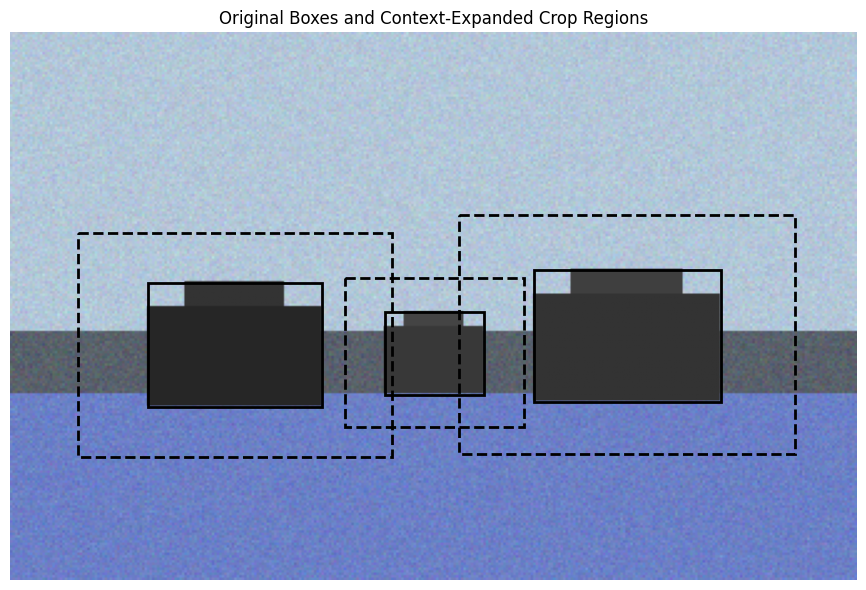

In [10]:

# Visualize original and expanded boxes

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(scene)

for det, exp_box in zip(detections, expanded_boxes):
    x1, y1, x2, y2, conf, cls = det
    ex1, ey1, ex2, ey2 = exp_box

    # Original box
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2))
    # Expanded box
    ax.add_patch(Rectangle((ex1, ey1), ex2 - ex1, ey2 - ey1, fill=False, linewidth=2, linestyle="--"))

ax.set_title("Original Boxes and Context-Expanded Crop Regions")
ax.axis("off")
plt.tight_layout()
plt.show()



In the figure above:
- **solid boxes** represent the original detections
- **dashed boxes** represent the context-expanded regions used for downstream flood analysis


In [11]:

# Extract original and expanded crops

original_crops = []
expanded_crops = []

for det, exp_box in zip(detections, expanded_boxes):
    x1, y1, x2, y2, conf, cls = det
    ex1, ey1, ex2, ey2 = exp_box

    original_crop = scene[y1:y2, x1:x2]
    expanded_crop = scene[ey1:ey2, ex1:ex2]

    original_crops.append(original_crop)
    expanded_crops.append(expanded_crop)

print("Number of original crops:", len(original_crops))
print("Number of expanded crops:", len(expanded_crops))


Number of original crops: 3
Number of expanded crops: 3


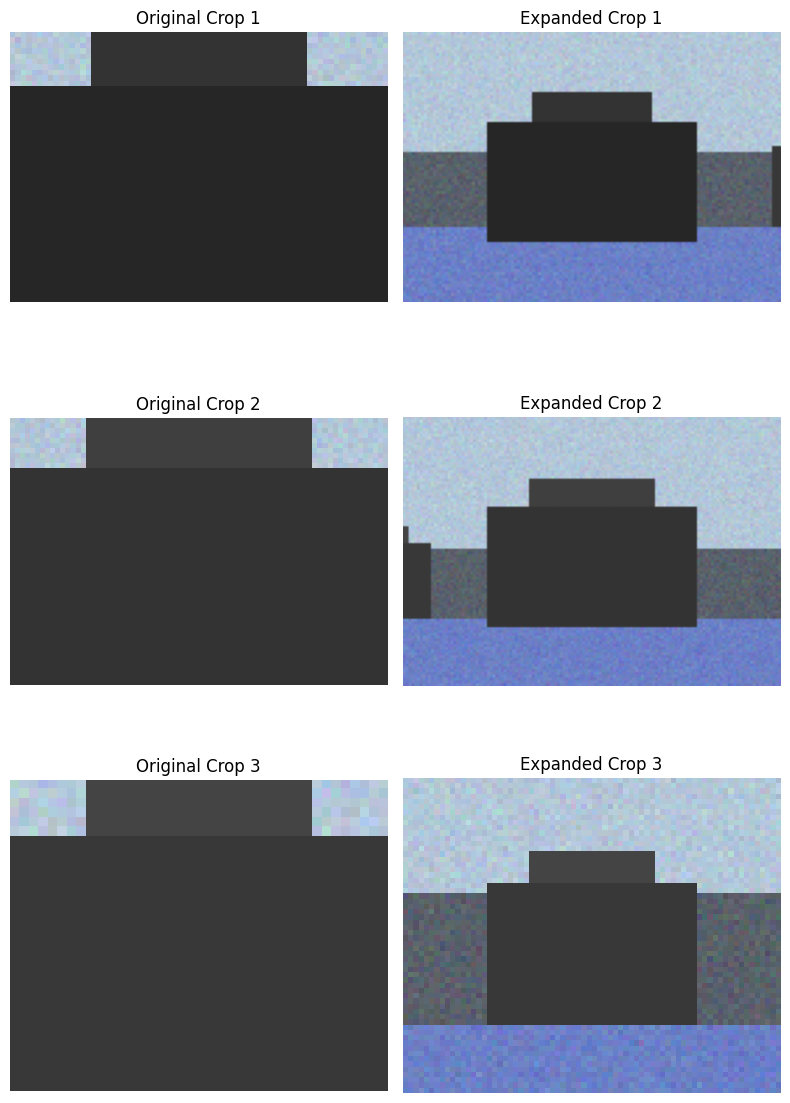

In [12]:

# Compare original vs expanded crops

num_crops = len(original_crops)
fig, axes = plt.subplots(num_crops, 2, figsize=(8, 4 * num_crops))

if num_crops == 1:
    axes = np.array([axes])

for i in range(num_crops):
    axes[i, 0].imshow(original_crops[i])
    axes[i, 0].set_title(f"Original Crop {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(expanded_crops[i])
    axes[i, 1].set_title(f"Expanded Crop {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()



## What Students Should Notice

The expanded crop usually contains:
- more of the floodwater area around the vehicle
- additional context for waterline interpretation
- reflections and local scene texture
- information that a classifier can use to infer severity

This matters because downstream flood-depth estimation is often **context-sensitive**.



## Example: How a Real Detector Call Would Look

The exact detector may differ, but a real detection workflow could look like the following.


In [13]:

# Example detector inference pattern
# Uncomment when using a real detector

# image_path = "example_flood_image.jpg"
# results = model(image_path)

# for result in results:
#     for box in result.boxes:
#         xyxy = box.xyxy[0].cpu().numpy()
#         conf = float(box.conf[0].cpu().numpy())
#         cls_id = int(box.cls[0].cpu().numpy())
#         print(xyxy, conf, cls_id)



## Preparing Data for the Next Stage

The output of this stage is not yet a flood severity prediction.  
Instead, the output is a set of **vehicle-centered regions of interest** that are ready for:
- image enhancement
- flood-depth classification
- confidence-weighted fusion
- image-level aggregation

This sets up the Week 6 notebook, which will move from **detection and cropping** to **full flood-depth estimation**.


In [14]:

# Summarize crop metadata

crop_metadata = []

for idx, (det, exp_box) in enumerate(zip(detections, expanded_boxes), start=1):
    x1, y1, x2, y2, conf, cls = det
    ex1, ey1, ex2, ey2 = exp_box

    crop_metadata.append({
        "crop_id": idx,
        "class_name": cls,
        "confidence": round(conf, 2),
        "orig_width": x2 - x1,
        "orig_height": y2 - y1,
        "expanded_width": ex2 - ex1,
        "expanded_height": ey2 - ey1
    })

crop_metadata_df = pd.DataFrame(crop_metadata)
crop_metadata_df


,crop_id,class_name,confidence,orig_width,orig_height,expanded_width,expanded_height
0,1,vehicle,0.94,70,50,126,90
1,2,vehicle,0.91,75,53,135,96
2,3,vehicle,0.83,40,33,72,60



## Mini Exercise

Answer the following in your own words:

1. Why are vehicles useful reference objects for flood analysis?
2. Why is the expanded crop often better than the original bounding box alone?
3. What information is still missing after this notebook that is needed for final flood-depth prediction?

Write your responses below.


In [15]:

# Write your Week 5 mini exercise responses here

# 1.
# 2.
# 3.



## Weekly Assignment

Choose one of the following tasks:

### Option A
Write a short explanation of the full Week 5 workflow:
- image input
- vehicle detection
- crop expansion
- crop export
- preparation for downstream flood classification

### Option B
Modify the synthetic scene by:
- adding one more vehicle
- defining its detection box
- generating the expanded crop
- visualizing the updated result

Then explain how the added vehicle might affect downstream flood interpretation.


In [16]:

# Week 5 assignment response area

workflow_explanation = ""
added_vehicle_notes = ""

print("Workflow Explanation:", workflow_explanation)
print("Added Vehicle Notes:", added_vehicle_notes)


Workflow Explanation: 
Added Vehicle Notes: 



## Key Takeaway

The main lesson from Week 5 is:

> **Vehicle detection is not the end goal — it is the first step toward interpreting urban flood severity.**

By detecting vehicles and extracting context-rich crops, we transform a full street scene into a set of structured image regions that are much more useful for downstream flood intelligence.



## Suggested Extensions

Later versions of this notebook can be expanded with:
- real urban flood images
- a pretrained YOLO detector
- non-maximum suppression discussion
- confidence threshold tuning
- crop export to disk
- visual comparison between tight and loose cropping
- linking detections to downstream severity labels

This keeps the current notebook beginner-friendly while making it easy to extend into a full research or deployment workflow.
